# Fly connectome bimodularity
Reproduces the bimodularity-style experiments from the `Bimodularity-Figures` notebook on the fly connectome (`connections_princeton.csv`). The notebook builds a directed weighted graph, computes a directed modularity matrix, performs SVD, clusters edges into bicommunities, and visualizes the resulting sending/receiving communities with rich plots.


In [51]:
import sys
print("Notebook python:", sys.executable)

# If you need to (re)install deps in a fresh environment, prefer:
# !{sys.executable} -m pip install -r ../requirements.txt


Notebook python: c:\Users\20211927\AppData\Local\Programs\Python\Python310\python.exe


In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from pathlib import Path
from sklearn.cluster import KMeans
from matplotlib.gridspec import GridSpec

sns.set_context('talk')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlepad'] = 12


In [53]:
from pathlib import Path

# Try to locate repo root regardless of notebook working directory
_CWD = Path.cwd().resolve()
if (_CWD / "data").exists():
    REPO_ROOT = _CWD
elif (_CWD.parent / "data").exists():
    REPO_ROOT = _CWD.parent
else:
    raise FileNotFoundError(f"Could not locate repo root from cwd={_CWD}")

DATA_DIR = REPO_ROOT / "data" / "raw"
CONNECTIONS_PATH = DATA_DIR / "connections_princeton.csv"
ANNOTATIONS_PATH = DATA_DIR / "labels.csv"

N_CLUSTERS = 20
N_VECTORS = 8
MAX_NODES = 1000
EDGE_WEIGHT_COL = "syn_count"
MIN_SYN = 10
RANDOM_STATE = 0

# How to pick the "pipeline" bicommunity for downstream plots / hierarchy:
# - "max_q": highest bimodularity score (paper-dominant)
# - "largest": most edges (often more mixed / interpretable)
# - "interpretable": select PN->KC and KC->MBON clusters (more pathway-like)
PIPELINE_MODE = "interpretable"

# For PIPELINE_MODE="interpretable": avoid picking tiny clusters.
PIPELINE_MIN_TYPE_EDGES = 100

# How to define "subclusters" inside the pipeline for downstream plots:
# - "pipeline_clusters": use the selected top-level pipeline clusters as subclusters
# - "recluster": run a second k-means inside the pipeline subgraph
HIERARCHY_MODE = "pipeline_clusters"
N_SUBCLUSTERS = 6

assert CONNECTIONS_PATH.exists(), f"{CONNECTIONS_PATH} missing"
assert ANNOTATIONS_PATH.exists(), f"{ANNOTATIONS_PATH} missing"

print("Repo root:", REPO_ROOT)
print("Connections:", CONNECTIONS_PATH)
print("Labels:", ANNOTATIONS_PATH)


Repo root: C:\Users\20211927\OneDrive - TU Eindhoven\Documents\GitHub\flywire-connectome-analysis
Connections: C:\Users\20211927\OneDrive - TU Eindhoven\Documents\GitHub\flywire-connectome-analysis\data\raw\connections_princeton.csv
Labels: C:\Users\20211927\OneDrive - TU Eindhoven\Documents\GitHub\flywire-connectome-analysis\data\raw\labels.csv


In [54]:
connections = pd.read_csv(CONNECTIONS_PATH)
connections = connections[['pre_root_id', 'post_root_id', EDGE_WEIGHT_COL, 'neuropil', 'nt_type']]
connections.head()


,pre_root_id,post_root_id,syn_count,neuropil,nt_type
0,720575940625363947,720575940623224444,12,ME_L,GABA
1,720575940630432382,720575940618518557,67,ME_L,ACH
2,720575940627314521,720575940626337738,10,ME_L,GABA
3,720575940620280405,720575940620204726,15,ME_L,ACH
4,720575940636942447,720575940613789411,1,LA_L,GLUT


In [55]:
ann = pd.read_csv(ANNOTATIONS_PATH)
ann.columns = [c.strip() for c in ann.columns]
print("Annotation columns:", ann.columns.tolist())

# labels.csv typically contains multiple labels per root_id; we use pattern matches.
if "label" in ann.columns:
    for pat in ["MBON", "Kenyon_Cell", "ALPN", "TPN"]:
        hits = ann["label"].dropna().astype(str).str.contains(pat, case=False, regex=False)
        print(f"{pat}: {hits.sum()} label-rows | {ann.loc[hits, 'root_id'].nunique()} unique root_ids")
else:
    raise ValueError("Expected a 'label' column in labels.csv")


Annotation columns: ['root_id', 'label', 'user_id', 'position', 'supervoxel_id', 'label_id', 'date_created', 'user_name', 'user_affiliation']
MBON: 216 label-rows | 102 unique root_ids
Kenyon_Cell: 3166 label-rows | 3145 unique root_ids
ALPN: 683 label-rows | 681 unique root_ids
TPN: 3 label-rows | 3 unique root_ids


## Preprocess graph (reindex, optionally filter)
- Compute per-node strength (incoming + outgoing synapses).
- Keep the top `TOP_N_NODES` strongest nodes to keep matrices workable.
- Reindex nodes to consecutive integers for dense matrices.


In [56]:
# 1) Define ROI nodes by annotation label
label_series = ann["label"].fillna("").astype(str)

pns = set(ann.loc[label_series.str.contains(r"\b(ALPN|TPN)\b", case=False, regex=True), "root_id"].astype(int))
kcs = set(ann.loc[label_series.str.contains("Kenyon_Cell", case=False, regex=False), "root_id"].astype(int))
mbons = set(ann.loc[label_series.str.contains("MBON", case=False, regex=False), "root_id"].astype(int))

roi_nodes = pns | kcs | mbons
print(f"PN: {len(pns)}, KC: {len(kcs)}, MBON: {len(mbons)}")
print(f"ROI nodes (before pruning): {len(roi_nodes)}")

# 2) Keep ALL directed edges among ROI nodes (direction preserved)
connections_roi = connections[
    connections["pre_root_id"].isin(roi_nodes)
    & connections["post_root_id"].isin(roi_nodes)
].copy()
print("Edges in ROI (before pruning):", len(connections_roi))

# 3) Optional noise filter: prune weak edges
connections_roi = connections_roi[connections_roi[EDGE_WEIGHT_COL] >= MIN_SYN].copy()
print("Edges after synapse threshold:", len(connections_roi))

# 4) Cap nodes by total strength within ROI
out_strength = connections_roi.groupby("pre_root_id")[EDGE_WEIGHT_COL].sum()
in_strength = connections_roi.groupby("post_root_id")[EDGE_WEIGHT_COL].sum()
strength = out_strength.add(in_strength, fill_value=0)

keep_nodes = strength.sort_values(ascending=False).head(MAX_NODES).index
connections_roi = connections_roi[
    connections_roi["pre_root_id"].isin(keep_nodes)
    & connections_roi["post_root_id"].isin(keep_nodes)
].copy()

print("Final nodes:", len(keep_nodes))
print("Final edges:", len(connections_roi))

keep_set = set(keep_nodes)
print("Kept PN:", len(keep_set & pns))
print("Kept KC:", len(keep_set & kcs))
print("Kept MBON:", len(keep_set & mbons))

# ===== build adj from connections_roi (NOT from full connections) =====
node_list = pd.Index(sorted(keep_nodes))
node_to_idx = {n: i for i, n in enumerate(node_list)}

connections_roi["pre_idx"] = connections_roi["pre_root_id"].map(node_to_idx)
connections_roi["post_idx"] = connections_roi["post_root_id"].map(node_to_idx)

n = len(node_list)
adj = np.zeros((n, n), dtype=float)
for _, row in connections_roi.iterrows():
    adj[int(row["pre_idx"]), int(row["post_idx"])] += row[EDGE_WEIGHT_COL]

print(f"Nodes kept: {n}, edges kept: {len(connections_roi):,}, total synapses: {connections_roi[EDGE_WEIGHT_COL].sum():,}")


C:\Users\20211927\AppData\Local\Temp\ipykernel_15476\3212325276.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  pns = set(ann.loc[label_series.str.contains(r"\b(ALPN|TPN)\b", case=False, regex=True), "root_id"].astype(int))


PN: 682, KC: 3145, MBON: 102
ROI nodes (before pruning): 3928
Edges in ROI (before pruning): 86740
Edges after synapse threshold: 15922
Final nodes: 1000
Final edges: 5923
Kept PN: 385
Kept KC: 541
Kept MBON: 75
Nodes kept: 1000, edges kept: 5,923, total synapses: 143,152


## Helper functions (directed modularity, SVD, bicommunities)
These replicate the logic of the original bimodularity utilities inside the notebook.


In [57]:
from typing import Tuple


def modularity_matrix(A: np.ndarray, null_model: str = "outin") -> np.ndarray:
    """Directed modularity matrix with out*in (configuration) null."""
    kout = A.sum(axis=1, keepdims=True)
    kin = A.sum(axis=0, keepdims=True)
    m = A.sum()
    if m == 0:
        return np.zeros_like(A)
    if null_model != "outin":
        raise ValueError("Only 'outin' null model supported here")
    P = kout @ kin / m
    return A - P


def sorted_svd(B: np.ndarray, signed: bool = True) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """SVD of B sorted by |singular value|, with optional sign convention on S.

    Paper sign convention: sign is set by the dot product between left/right vectors.
    For clustering distances, using |S| vs signed S is equivalent up to an orthogonal flip.
    """
    U, S, Vt = np.linalg.svd(B, full_matrices=False)
    order = np.argsort(S)[::-1]
    U = U[:, order]
    S = S[order]
    V = Vt[order].T

    if signed:
        cosine_uv = np.sum(U * V, axis=0)
        sign = np.sign(cosine_uv)
        sign[sign == 0] = 1
        S = S * sign

    return U, S, V


def edge_features(edge_u: np.ndarray, edge_v: np.ndarray, U: np.ndarray, V: np.ndarray, S: np.ndarray, n_vectors: int) -> np.ndarray:
    """Paper feature vector for an edge (i,j): (σ1 u1[i], σ1 v1[j], ..., σN uN[i], σN vN[j])."""
    scale = S[:n_vectors]
    return np.hstack([U[edge_u, :n_vectors] * scale, V[edge_v, :n_vectors] * scale])


def cluster_edges_kmeans(
    edge_u: np.ndarray,
    edge_v: np.ndarray,
    U: np.ndarray,
    V: np.ndarray,
    S: np.ndarray,
    n_vectors: int,
    n_clusters: int,
    random_state: int = 0,
):
    X = edge_features(edge_u, edge_v, U, V, S, n_vectors=n_vectors)
    km = KMeans(n_clusters=n_clusters, n_init=50, random_state=random_state)
    labels = km.fit_predict(X) + 1  # 1..K like paper notebook expects
    return labels, X, km


def bicommunity_node_sets(edge_u: np.ndarray, edge_v: np.ndarray, edge_labels: np.ndarray, n_clusters: int):
    send_sets = []
    recv_sets = []
    for k in range(1, n_clusters + 1):
        mask = edge_labels == k
        send_sets.append(np.unique(edge_u[mask]))
        recv_sets.append(np.unique(edge_v[mask]))
    return send_sets, recv_sets


def bimodularity_scores(A: np.ndarray, send_sets, recv_sets, scale: bool = True) -> np.ndarray:
    """Per-bicommunity bimodularity score (Eq. 2 block sum), optionally scaled by 1/m."""
    kout = A.sum(axis=1)
    kin = A.sum(axis=0)
    m = A.sum()
    scores = np.zeros(len(send_sets), dtype=float)
    if m == 0:
        return scores

    for idx, (send_idx, recv_idx) in enumerate(zip(send_sets, recv_sets)):
        if len(send_idx) == 0 or len(recv_idx) == 0:
            continue
        observed = A[np.ix_(send_idx, recv_idx)].sum()
        expected = kout[send_idx].sum() * kin[recv_idx].sum() / m
        val = observed - expected
        if scale:
            val /= m
        scores[idx] = val

    return scores


## Spectrum and leading singular vectors
We inspect the singular values of the directed modularity matrix and visualize the leading sending/receiving components.


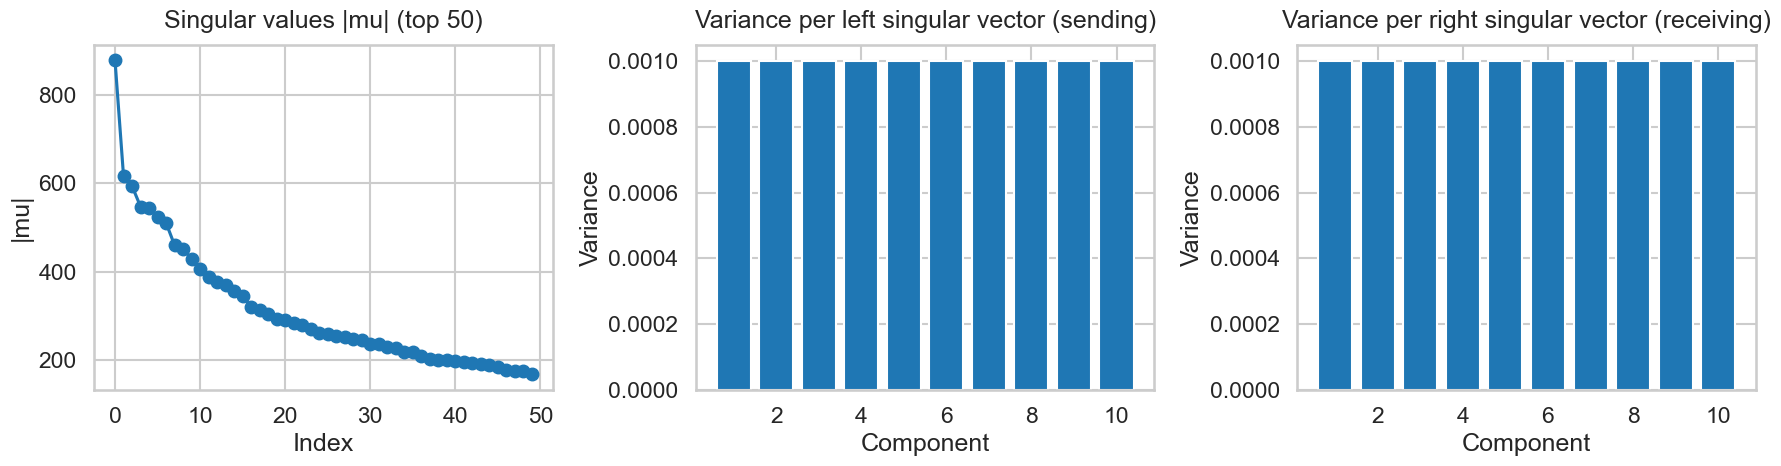

In [58]:
B = modularity_matrix(adj, null_model="outin")
U, S, V = sorted_svd(B, signed=True)

absS = np.abs(S)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(absS[:50], marker="o")
axes[0].set_title("Singular values |mu| (top 50)")
axes[0].set_xlabel("Index")
axes[0].set_ylabel("|mu|")

axes[1].bar(range(1, 11), U[:, :10].var(axis=0))
axes[1].set_title("Variance per left singular vector (sending)")
axes[1].set_xlabel("Component")
axes[1].set_ylabel("Variance")

axes[2].bar(range(1, 11), V[:, :10].var(axis=0))
axes[2].set_title("Variance per right singular vector (receiving)")
axes[2].set_xlabel("Component")
axes[2].set_ylabel("Variance")

plt.tight_layout()
plt.show()


In [59]:
absS = np.abs(S)
print(absS[:10])
print("Ratios |S[k]|/|S[k+1]| (top 9):")
print(absS[:9] / absS[1:10])

# node_list: Index of root_ids in the same order as rows of adj/B/U/V
root_ids = np.array(node_list, dtype=int)

labels = np.array(["Other"] * len(root_ids), dtype=object)
labels[np.isin(root_ids, list(pns))] = "PN"
labels[np.isin(root_ids, list(kcs))] = "KC"
labels[np.isin(root_ids, list(mbons))] = "MBON"

print(pd.Series(labels).value_counts())


[878.44174979 616.8394774  593.92043046 547.28236066 544.48411983
 523.08669573 510.41141852 459.87836026 451.54077167 428.89523877]
Ratios |S[k]|/|S[k+1]| (top 9):
[1.42410105 1.03858942 1.08521756 1.00513925 1.04090608 1.02483345
 1.10988353 1.01846475 1.05279968]
KC      540
PN      385
MBON     75
Name: count, dtype: int64


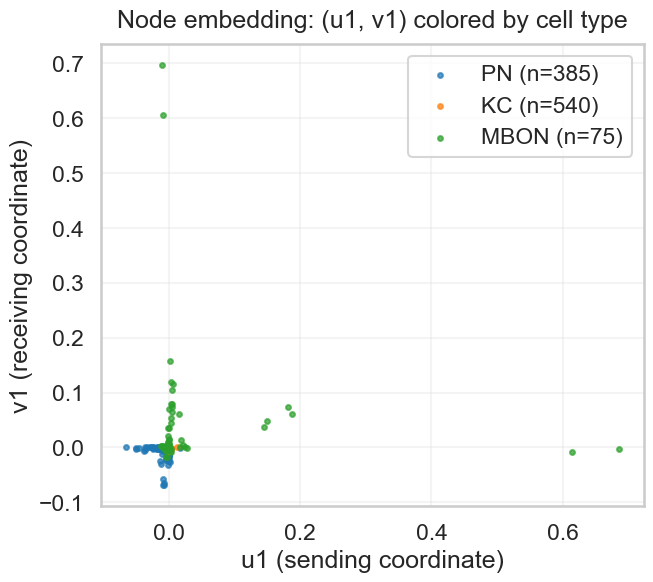

In [60]:
u1 = U[:, 0]  # first left singular vector (sending)
v1 = V[:, 0]  # first right singular vector (receiving)

plt.figure(figsize=(7, 6))

for t in ["PN", "KC", "MBON", "Other"]:
    mask = (labels == t)
    if mask.sum() == 0:
        continue
    plt.scatter(u1[mask], v1[mask], s=12, alpha=0.7, label=f"{t} (n={mask.sum()})")

plt.xlabel("u1 (sending coordinate)")
plt.ylabel("v1 (receiving coordinate)")
plt.title("Node embedding: (u1, v1) colored by cell type")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()


In [61]:
N = N_VECTORS
K = N_CLUSTERS

# Cluster observed edges A_ij>0 using paper feature vector
edge_u, edge_v = np.nonzero(adj)
edge_labels, X, km = cluster_edges_kmeans(
    edge_u,
    edge_v,
    U,
    V,
    S,
    n_vectors=N,
    n_clusters=K,
    random_state=RANDOM_STATE,
)

# Map edge labels back to the ROI edge table (many-to-one: multiple rows can share same (pre,post))
edges = pd.DataFrame({"pre_idx": edge_u, "post_idx": edge_v, "edge_cluster": edge_labels})
connections_roi = connections_roi.merge(edges, on=["pre_idx", "post_idx"], how="left", validate="many_to_one")
assert connections_roi["edge_cluster"].notna().all(), "Some edges did not get a cluster label"
connections_roi["edge_cluster"] = connections_roi["edge_cluster"].astype(int)

# Compute bimodularity scores per bicommunity (paper Eq. 2) and overall Q_bi
send_sets, recv_sets = bicommunity_node_sets(edge_u, edge_v, edge_labels, n_clusters=K)
q = bimodularity_scores(adj, send_sets, recv_sets, scale=True)

score_df = pd.DataFrame(
    {
        "cluster": np.arange(1, K + 1, dtype=int),
        "bimodularity": q,
        "n_edges": [int((edge_labels == k).sum()) for k in range(1, K + 1)],
        "send_size": [int(len(send_sets[k - 1])) for k in range(1, K + 1)],
        "recv_size": [int(len(recv_sets[k - 1])) for k in range(1, K + 1)],
    }
).sort_values("bimodularity", ascending=False)

Q_overall = float(score_df["bimodularity"].mean())
print(f"Overall Q_bi (Eq. 2): {Q_overall:.6f}")
score_df.head(10)

TOP_CLUSTER = int(score_df.iloc[0]["cluster"])
print("TOP_CLUSTER (highest bimodularity):", TOP_CLUSTER)


Overall Q_bi (Eq. 2): 0.028173
TOP_CLUSTER (highest bimodularity): 1


In [62]:
def summarize_cluster(df: pd.DataFrame, c: int):
    sub = df[df["edge_cluster"] == c]
    src = sub["pre_idx"].to_numpy(int)
    tgt = sub["post_idx"].to_numpy(int)
    src_types = pd.Series(labels[src]).value_counts(normalize=True)
    tgt_types = pd.Series(labels[tgt]).value_counts(normalize=True)
    return len(sub), src_types, tgt_types

for row in score_df.itertuples(index=False):
    c = int(row.cluster)
    m, src_mix, tgt_mix = summarize_cluster(connections_roi, c)
    print(f"\nCluster {c}: Q={row.bimodularity:.4g} | edges={m} | send={row.send_size} | recv={row.recv_size}")
    print("  source mix (%):", (src_mix * 100).round(1).to_dict())
    print("  target mix (%):", (tgt_mix * 100).round(1).to_dict())



Cluster 1: Q=0.09839 | edges=2892 | send=458 | recv=758
  source mix (%): {'PN': 87.9, 'KC': 6.2, 'MBON': 5.9}
  target mix (%): {'KC': 48.5, 'PN': 39.6, 'MBON': 11.8}

Cluster 11: Q=0.07292 | edges=625 | send=50 | recv=234
  source mix (%): {'PN': 100.0}
  target mix (%): {'KC': 70.4, 'PN': 29.0, 'MBON': 0.6}

Cluster 9: Q=0.06713 | edges=611 | send=20 | recv=335
  source mix (%): {'PN': 100.0}
  target mix (%): {'KC': 87.6, 'PN': 12.4}

Cluster 10: Q=0.0668 | edges=447 | send=230 | recv=52
  source mix (%): {'MBON': 48.1, 'KC': 48.1, 'PN': 3.8}
  target mix (%): {'MBON': 99.8, 'PN': 0.2}

Cluster 3: Q=0.03694 | edges=275 | send=3 | recv=198
  source mix (%): {'PN': 100.0}
  target mix (%): {'KC': 87.3, 'PN': 12.4, 'MBON': 0.4}

Cluster 14: Q=0.03352 | edges=201 | send=4 | recv=134
  source mix (%): {'PN': 100.0}
  target mix (%): {'KC': 80.1, 'PN': 19.9}

Cluster 18: Q=0.02632 | edges=84 | send=24 | recv=14
  source mix (%): {'MBON': 79.8, 'PN': 20.2}
  target mix (%): {'MBON': 100.

In [63]:
def node_type(r):
    if r in pns: return "PN"
    if r in kcs: return "KC"
    if r in mbons: return "MBON"
    return "Other"

connections_roi["pre_type"]  = connections_roi["pre_root_id"].map(node_type)
connections_roi["post_type"] = connections_roi["post_root_id"].map(node_type)

ct = pd.crosstab(connections_roi["pre_type"], connections_roi["post_type"])
print(ct)

print("KC->MBON edges:", ((connections_roi["pre_type"]=="KC") & (connections_roi["post_type"]=="MBON")).sum())


post_type    KC  MBON    PN
pre_type                   
KC            6   443     0
MBON          3   644    35
PN         2810    66  1916
KC->MBON edges: 443


In [64]:
kc_mbon = connections_roi[(connections_roi["pre_type"]=="KC") & (connections_roi["post_type"]=="MBON")]
print(kc_mbon["edge_cluster"].value_counts().head(20))


edge_cluster
10    215
1     173
17     49
5       5
20      1
Name: count, dtype: int64


In [65]:
# One row per observed (pre_idx, post_idx) edge in adj
edge_types = edges.copy()
edge_types["pre_type"] = labels[edge_types["pre_idx"].to_numpy(int)]
edge_types["post_type"] = labels[edge_types["post_idx"].to_numpy(int)]

def _best_cluster_for_edge_type(pre_type: str, post_type: str, min_type_edges: int = PIPELINE_MIN_TYPE_EDGES):
    """Pick a cluster that is both (i) enriched for a type-pair and (ii) not tiny."""
    sub = edge_types[(edge_types["pre_type"] == pre_type) & (edge_types["post_type"] == post_type)]
    if sub.empty:
        return None

    total_edges = edge_types.groupby("edge_cluster").size()
    type_edges = sub.groupby("edge_cluster").size()

    candidates = type_edges[type_edges >= min_type_edges]
    if candidates.empty:
        candidates = type_edges

    purity = candidates / total_edges.loc[candidates.index]
    score = purity * np.log1p(candidates.astype(float))
    return int(score.sort_values(ascending=False).index[0])

# Select which bicommunity(ies) define the pipeline.
if PIPELINE_MODE == "max_q":
    PIPELINE_CLUSTERS = [TOP_CLUSTER]
elif PIPELINE_MODE == "largest":
    PIPELINE_CLUSTERS = [int(score_df.sort_values("n_edges", ascending=False).iloc[0]["cluster"])]
elif PIPELINE_MODE == "interpretable":
    c_pn_kc = _best_cluster_for_edge_type("PN", "KC")
    c_kc_mbon = _best_cluster_for_edge_type("KC", "MBON")
    PIPELINE_CLUSTERS = [c for c in (c_pn_kc, c_kc_mbon) if c is not None]
    PIPELINE_CLUSTERS = list(dict.fromkeys(PIPELINE_CLUSTERS))  # unique, preserve order
    if not PIPELINE_CLUSTERS:
        PIPELINE_CLUSTERS = [TOP_CLUSTER]
else:
    raise ValueError(f"Unknown PIPELINE_MODE={PIPELINE_MODE!r}")

pipeline = connections_roi[connections_roi["edge_cluster"].isin(PIPELINE_CLUSTERS)].copy()

# Remap selected clusters to compact subcluster ids: 1..len(PIPELINE_CLUSTERS)
PIPELINE_CLUSTER_TO_SUB = {c: i + 1 for i, c in enumerate(PIPELINE_CLUSTERS)}
pipeline["pipeline_subcluster"] = pipeline["edge_cluster"].map(PIPELINE_CLUSTER_TO_SUB).astype(int)

src_mix = pipeline["pre_type"].value_counts(normalize=True)
tgt_mix = pipeline["post_type"].value_counts(normalize=True)

print("PIPELINE_MODE:", PIPELINE_MODE)
print("PIPELINE_CLUSTERS:", PIPELINE_CLUSTERS)
print("PIPELINE_CLUSTER_TO_SUB:", PIPELINE_CLUSTER_TO_SUB)
print(
    score_df.set_index("cluster")
    .loc[PIPELINE_CLUSTERS, ["bimodularity", "n_edges", "send_size", "recv_size"]]
)
print("Pipeline edge-type table (counts):")
print(pd.crosstab(pipeline["pre_type"], pipeline["post_type"]))
print("KC->MBON edges in pipeline:", int(((pipeline["pre_type"] == "KC") & (pipeline["post_type"] == "MBON")).sum()))
print("Source mix (%):", (src_mix * 100).round(1))
print("Target mix (%):", (tgt_mix * 100).round(1))

print("\nSource counts:")
print(pipeline["pre_type"].value_counts())

print("\nTarget counts:")
print(pipeline["post_type"].value_counts())


PIPELINE_MODE: interpretable
PIPELINE_CLUSTERS: [9, 10]
PIPELINE_CLUSTER_TO_SUB: {9: 1, 10: 2}
         bimodularity  n_edges  send_size  recv_size
cluster                                             
9            0.067126      610         20        335
10           0.066805      362        230         52
Pipeline edge-type table (counts):
post_type   KC  MBON  PN
pre_type                
KC           0   215   0
MBON         0   214   1
PN         535    17  76
KC->MBON edges in pipeline: 215
Source mix (%): pre_type
PN      59.4
MBON    20.3
KC      20.3
Name: proportion, dtype: float64
Target mix (%): post_type
KC      50.6
MBON    42.2
PN       7.3
Name: proportion, dtype: float64

Source counts:
pre_type
PN      628
MBON    215
KC      215
Name: count, dtype: int64

Target counts:
post_type
KC      535
MBON    446
PN       77
Name: count, dtype: int64


In [66]:
sub = pipeline.copy()

if HIERARCHY_MODE == "pipeline_clusters":
    # Use the selected top-level pipeline clusters as the hierarchy levels.
    sub["sub_cluster"] = sub["pipeline_subcluster"].astype(int)
elif HIERARCHY_MODE == "recluster":
    # Re-run k-means inside the induced subgraph on pipeline nodes.
    sub_nodes = pd.Index(sorted(set(sub["pre_idx"]) | set(sub["post_idx"])))
    sub_edges = connections_roi[
        connections_roi["pre_idx"].isin(sub_nodes) & connections_roi["post_idx"].isin(sub_nodes)
    ].copy()

    old_to_new = {old: i for i, old in enumerate(sub_nodes)}
    sub_edges["pre_sub"] = sub_edges["pre_idx"].map(old_to_new).astype(int)
    sub_edges["post_sub"] = sub_edges["post_idx"].map(old_to_new).astype(int)

    n2 = len(sub_nodes)
    adj2 = np.zeros((n2, n2), dtype=float)
    agg = sub_edges.groupby(["pre_sub", "post_sub"], as_index=False)[EDGE_WEIGHT_COL].sum()
    for _, row in agg.iterrows():
        adj2[int(row["pre_sub"]), int(row["post_sub"])] = row[EDGE_WEIGHT_COL]

    B2 = modularity_matrix(adj2, null_model="outin")
    U2, S2, V2 = sorted_svd(B2, signed=True)

    N2 = min(N_VECTORS, U2.shape[1])
    K2 = int(N_SUBCLUSTERS)
    edge_u2, edge_v2 = np.nonzero(adj2)
    edge_labels2, X2, km2 = cluster_edges_kmeans(
        edge_u2,
        edge_v2,
        U2,
        V2,
        S2,
        n_vectors=N2,
        n_clusters=K2,
        random_state=RANDOM_STATE,
    )

    edges2 = pd.DataFrame({"pre_sub": edge_u2, "post_sub": edge_v2, "sub_cluster": edge_labels2})
    sub_edges = sub_edges.merge(edges2, on=["pre_sub", "post_sub"], how="left", validate="many_to_one")
    assert sub_edges["sub_cluster"].notna().all()
    sub_edges["sub_cluster"] = sub_edges["sub_cluster"].astype(int)
    sub = sub_edges
else:
    raise ValueError(f"Unknown HIERARCHY_MODE={HIERARCHY_MODE!r}")

# show PN/KC/MBON enrichment per subcluster
for c in sorted(sub["sub_cluster"].unique()):
    s = sub[sub["sub_cluster"] == c]
    print(
        c,
        len(s),
        (s["pre_type"].value_counts(normalize=True) * 100).round(1).to_dict(),
        (s["post_type"].value_counts(normalize=True) * 100).round(1).to_dict(),
    )


1 611 {'PN': 100.0} {'KC': 87.6, 'PN': 12.4}
2 447 {'MBON': 48.1, 'KC': 48.1, 'PN': 3.8} {'MBON': 99.8, 'PN': 0.2}


In [67]:
import pandas as pd

from matplotlib.figure import Figure
from matplotlib.gridspec import GridSpecFromSubplotSpec

from matplotlib.lines import Line2D
import numpy as np
from scipy.linalg import block_diag
import networkx as nx

from typing import Optional

from matplotlib.axes import Axes
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from matplotlib.colors import to_rgb, to_rgba, ListedColormap
from matplotlib.patheffects import withStroke


def plot_graph_embedding(
    matrix: np.ndarray,
    vector_id: int = 0,
    n_com: int = 4,
    ax: Optional[Axes] = None,
    use_cmap: bool = True,
    cmap: str = "plasma",
    static_color: str = "tab:blue",
    write_label: bool = False,
    write_var: bool = False,
    label_lw: int = 3,
    directed_edges: bool = True,
    edge_alpha: float = 0.02,
    fontscale: float = 1.2,
    title_letter: str = "",
    override_title: Optional[str] = None,
    node_clusers: Optional[np.ndarray] = None,
    **kwargs,
) -> Axes:

    # Building the modularity matrix
    modmat = modularity_matrix(matrix, null_model="outin")

    U, S, V = sorted_svd(modmat, signed=True)

    n_nodes = matrix.shape[0]
    n_per_com = n_nodes // n_com

    graph_pos = {i: (U[i, vector_id], V[i, vector_id]) for i in range(n_nodes)}
    labels = {i: "" for i in range(n_nodes)}

    if ax is None:
        _, ax = plt.subplots(figsize=(8, 8))

    if directed_edges:
        graph = nx.DiGraph(matrix)
    else:
        graph = nx.Graph(matrix)

    nx.draw_networkx_edges(graph, pos=graph_pos, alpha=edge_alpha, ax=ax)

    if use_cmap:
        if node_clusers is None:
            palette_rgb = [to_rgb(color) for color in PALETTE]
            colors = [palette_rgb[i // n_per_com] for i in np.arange(n_nodes)]
        else:
            try:
                cmap = plt.get_cmap(cmap, int(node_clusers.max() + 1))
                colors = [cmap(int(i)) for i in node_clusers]
            except ValueError:
                colors = [cmap] * n_nodes
    else:
        colors = static_color

    ax.scatter(
        U[:, vector_id],
        V[:, vector_id],
        s=200,
        color=colors,
        edgecolor="k",
        linewidth=2,
        zorder=2,
    )

    if write_var:
        expl_var = S[vector_id] ** 2 / np.sum(S**2)
        ax.text(
            0.05,
            0.90,
            f"$R^2={expl_var:1.3f}$",
            transform=ax.transAxes,
            fontsize=16 * fontscale,
            path_effects=[
                withStroke(
                    linewidth=label_lw,
                    foreground="w",
                    alpha=0.8,
                )
            ],
        )

        angle = (V.T @ U)[vector_id, vector_id]
        ax.text(
            0.05,
            0.85,
            f"$\\mathbf{{v}}^T\\mathbf{{u}}={angle:1.2f}$",
            transform=ax.transAxes,
            fontsize=16 * fontscale,
            path_effects=[
                withStroke(
                    linewidth=label_lw,
                    foreground="w",
                    alpha=0.8,
                )
            ],
        )

    if write_label:
        for com_i in range(n_com):
            mean_u = np.mean(U[com_i * n_per_com : (com_i + 1) * n_per_com, vector_id])
            mean_v = np.mean(V[com_i * n_per_com : (com_i + 1) * n_per_com, vector_id])
            ax.text(
                mean_u,
                mean_v,
                f"$S_{com_i+1}$",
                fontsize=26 * fontscale,
                color="k",
                # color="w",
                # color=PALETTE[com_i],
                fontweight="bold",
                path_effects=[
                    withStroke(
                        linewidth=label_lw,
                        foreground="w",
                        alpha=0.8,
                        # foreground="k",
                        # foreground=PALETTE[com_i],
                    )
                ],
                ha="center",
                va="center",
                zorder=4,
            )
            # ax.scatter(
            #    mean_u, mean_v, s=1000, marker="o", color="w", alpha=0.8, zorder=3
            # )

    # Parameters
    ax.set_title(
        title_letter,
        loc="left",
        fontsize=22 * fontscale,
        fontdict={"fontweight": "bold"},
    )
    if override_title is None:
        override_title = f"Bimodularity Embedding $(n={{{vector_id+1}}})$"
    ax.set_title(override_title, fontsize=20 * fontscale)
    ax.tick_params(
        left=True,
        bottom=True,
        labelleft=True,
        labelbottom=True,
        labelsize=16 * fontscale,
        width=2,
    )
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[:].set_linewidth(2)

    ax.set_xticks(
        np.linspace(-0.1, 0.1, 3),
        labels=np.linspace(-0.1, 0.1, 3),
        fontsize=18 * fontscale,
    )
    ax.set_yticks(
        np.linspace(-0.1, 0.1, 3),
        labels=np.linspace(-0.1, 0.1, 3),
        fontsize=18 * fontscale,
    )

    ax.set_xlabel(
        f"Left Singular Vector $\\mathbf{{u}}_{{{vector_id+1}}}$",
        fontsize=18 * fontscale,
    )
    ax.set_ylabel(
        f"Right Singular Vector $\\mathbf{{v}}_{{{vector_id+1}}}$",
        fontsize=18 * fontscale,
    )

    return ax

def plot_bicommunity_types(
    sending_communities,
    receiving_communities,
    types,
    type_colors=None,
    titles=None,
    fontsize=14,
    fig=None,
    axes=None,
):

    if type_colors is None:
        cmap = plt.get_cmap("Set1")
        type_colors = {t: cmap(i) for i, t in enumerate(types.unique())}

    if titles is None:
        titles = [f"Community {com_i+1}" for com_i in range(len(sending_communities))]

    if axes is None:
        fig, axes = plt.subplots(figsize=(5 * len(sending_communities), 5))

    types_series = pd.Series(types)
    # print(types_series)

    for com_i, (s, r) in enumerate(zip(sending_communities, receiving_communities)):
        types_send = types_series[s > 0].value_counts()
        types_receive = types_series[r > 0].value_counts()

        # print(types_send, types_receive)

        axes[com_i].set_visible(False)
        gs_com = GridSpecFromSubplotSpec(
            2, 1, subplot_spec=axes[com_i].get_subplotspec(), hspace=0.05, wspace=0
        )
        axes_com = [fig.add_subplot(gs_com[i]) for i in range(2)]

        # axes_com[0].set_title(f"Community {com_i+1}", fontsize=20)
        # axes_com[0].set_title(titles[com_i], fontsize=20)

        # axes_com[0].set_title("Sending", fontsize=14)
        # axes_com[1].set_title("Receiving", fontsize=14)

        # axes_com[0].set_ylabel("Sending\n", fontsize=fontsize + 2, labelpad=-30)
        # axes_com[1].set_ylabel("Receiving\n", fontsize=fontsize + 2, labelpad=-30)

        axes_com[0].set_ylabel("Sending\n", fontsize=fontsize + 2, labelpad=0)
        axes_com[1].set_ylabel("Receiving\n", fontsize=fontsize + 2, labelpad=0)

        axes_com[0].yaxis.set_label_position("right")
        axes_com[1].yaxis.set_label_position("right")

        axes_com[0].pie(
            types_send,
            colors=[type_colors[t] for t in types_send.index],
            labels=types_send.index,
            labeldistance=0.6,
            # rotatelabels=True,
            wedgeprops={"edgecolor": "w", "linewidth": 2},
            textprops={"fontsize": fontsize, "ha": "center"},
            # textprops={"size": "smaller"},
        )
        axes_com[1].pie(
            types_receive,
            colors=[type_colors[t] for t in types_receive.index],
            labels=types_receive.index,
            labeldistance=0.6,
            # rotatelabels=True,
            wedgeprops={"edgecolor": "w", "linewidth": 2},
            textprops={"fontsize": fontsize, "ha": "center"},
            # textprops={"size": "smaller"},
        )

    return axes

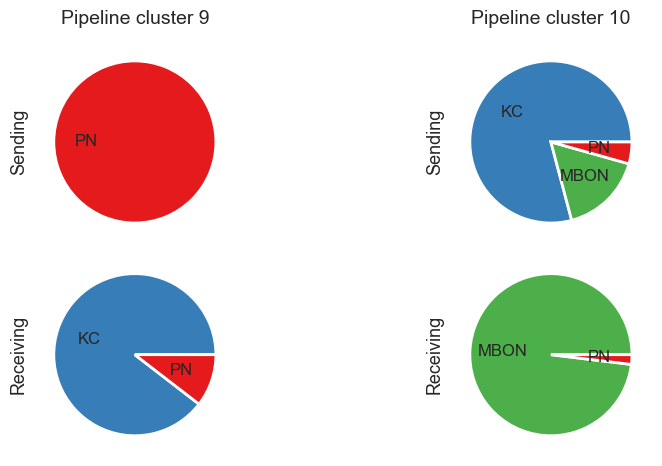

In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpecFromSubplotSpec

def plot_bicommunity_types_from_edges(
    df, cluster_col, cluster_ids, types, n_nodes,
    type_colors=None, titles=None, fontsize=12
):
    # types: array/Series of node types aligned with node indices 0..n_nodes-1
    types_series = pd.Series(types)

    if type_colors is None:
        cmap = plt.get_cmap("Set1")
        uniq = list(pd.unique(types_series))
        type_colors = {t: cmap(i) for i, t in enumerate(uniq)}

    if titles is None:
        titles = [f"Cluster {c}" for c in cluster_ids]

    fig, axes = plt.subplots(1, len(cluster_ids), figsize=(5*len(cluster_ids), 5))
    if len(cluster_ids) == 1:
        axes = [axes]

    for ax, c, title in zip(axes, cluster_ids, titles):
        subdf = df[df[cluster_col] == c]
        s = np.zeros(n_nodes, dtype=int)
        r = np.zeros(n_nodes, dtype=int)
        s[subdf["pre_idx"].unique()] = 1
        r[subdf["post_idx"].unique()] = 1

        types_send = types_series[s > 0].value_counts()
        types_recv = types_series[r > 0].value_counts()

        ax.set_visible(False)
        gs = GridSpecFromSubplotSpec(2, 1, subplot_spec=ax.get_subplotspec(), hspace=0.05)
        ax0 = fig.add_subplot(gs[0])
        ax1 = fig.add_subplot(gs[1])

        ax0.set_title(title, fontsize=fontsize+2)
        ax0.set_ylabel("Sending", fontsize=fontsize+1)
        ax1.set_ylabel("Receiving", fontsize=fontsize+1)

        ax0.pie(
            types_send,
            colors=[type_colors[t] for t in types_send.index],
            labels=types_send.index,
            labeldistance=0.6,
            wedgeprops={"edgecolor": "w", "linewidth": 2},
            textprops={"fontsize": fontsize, "ha": "center"},
        )
        ax1.pie(
            types_recv,
            colors=[type_colors[t] for t in types_recv.index],
            labels=types_recv.index,
            labeldistance=0.6,
            wedgeprops={"edgecolor": "w", "linewidth": 2},
            textprops={"fontsize": fontsize, "ha": "center"},
        )

    plt.tight_layout()
    return fig

# ---- Run it: show selected pipeline cluster(s) ----
n_nodes = adj.shape[0]
types = labels  # array of "PN"/"KC"/"MBON"

# Pipeline bicommunity(ies):
fig = plot_bicommunity_types_from_edges(
    connections_roi, "edge_cluster", cluster_ids=PIPELINE_CLUSTERS,
    types=types, n_nodes=n_nodes,
    titles=[f"Pipeline cluster {c}" for c in PIPELINE_CLUSTERS],
)
plt.show()

# If you want the hierarchical subclusters (sub dataframe must exist):
# fig = plot_bicommunity_types_from_edges(sub, "sub_cluster", cluster_ids=[1,2,3,4,5],
#     types=types, n_nodes=n_nodes, titles=[f"Pipeline subcluster {i}" for i in range(1, 6)])
# plt.show()


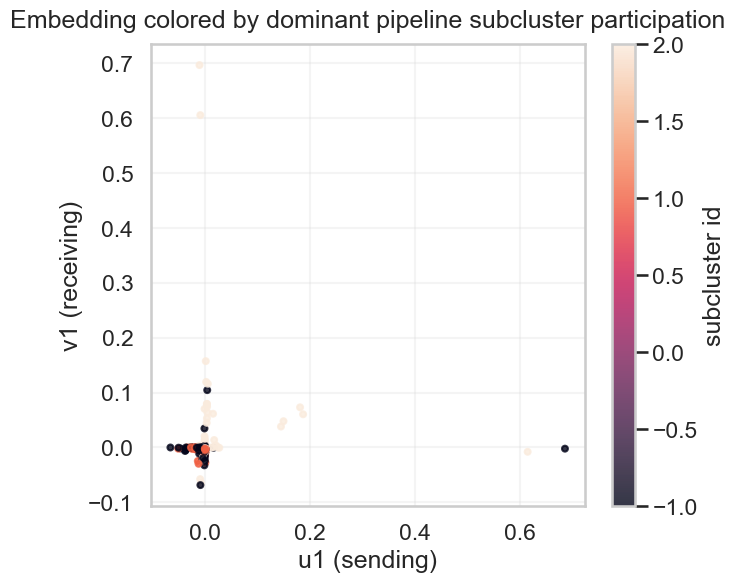

In [69]:
import numpy as np
import matplotlib.pyplot as plt

node_sub = np.full(adj.shape[0], -1, dtype=int)
counts = [dict() for _ in range(adj.shape[0])]

for _, row in sub.iterrows():
    c = int(row["sub_cluster"])
    i = int(row["pre_idx"]); j = int(row["post_idx"])
    counts[i][c] = counts[i].get(c, 0) + 1
    counts[j][c] = counts[j].get(c, 0) + 1

for i in range(adj.shape[0]):
    if counts[i]:
        node_sub[i] = max(counts[i], key=counts[i].get)

plt.figure(figsize=(7,6))
plt.scatter(u1, v1, c=node_sub, s=18, alpha=0.8)
plt.xlabel("u1 (sending)")
plt.ylabel("v1 (receiving)")
plt.title("Embedding colored by dominant pipeline subcluster participation")
plt.grid(True, alpha=0.2)
plt.colorbar(label="subcluster id")
plt.show()


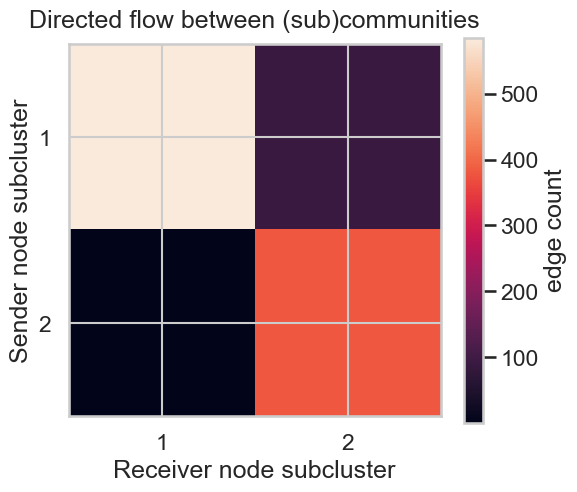

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Use subclusters within pipeline
df = sub.copy()

# Label each edge by its subcluster
K2 = df["sub_cluster"].nunique()

# Compute sender-subcluster vs receiver-subcluster counts (node-wise)
# We need node_sub labels (dominant subcluster per node) from Plot 2B:
sender_label = node_sub[df["pre_idx"].to_numpy(int)]
receiver_label = node_sub[df["post_idx"].to_numpy(int)]

flow = pd.crosstab(sender_label, receiver_label)

plt.figure(figsize=(6,5))
plt.imshow(flow.values)
plt.xticks(range(flow.shape[1]), flow.columns)
plt.yticks(range(flow.shape[0]), flow.index)
plt.xlabel("Receiver node subcluster")
plt.ylabel("Sender node subcluster")
plt.title("Directed flow between (sub)communities")
plt.colorbar(label="edge count")
plt.show()


In [71]:
import numpy as np
import pandas as pd

types = pd.Series(labels)          # length = n_nodes
node_sub_s = pd.Series(node_sub)   # length = n_nodes

# only nodes that have a subcluster assignment
mask = node_sub_s >= 0
df_nodes = pd.DataFrame({"subcluster": node_sub_s[mask].astype(int).values,
                         "type": types[mask].values})

comp = pd.crosstab(df_nodes["subcluster"], df_nodes["type"])
comp_pct = comp.div(comp.sum(axis=1), axis=0).fillna(0)

# Build human-readable labels based on dominant *edge-type* in each subcluster.
pair_df = (
    sub.assign(pair=sub["pre_type"].astype(str) + "->" + sub["post_type"].astype(str))
    .groupby(["sub_cluster", "pair"], as_index=False)
    .size()
    .rename(columns={"size": "n_edges"})
)
pair_df["pct"] = pair_df.groupby("sub_cluster")["n_edges"].transform(lambda x: x / x.sum())
dominant_pair = (
    pair_df.sort_values(["sub_cluster", "pct"], ascending=[True, False])
    .drop_duplicates("sub_cluster")
    .set_index("sub_cluster")
)

subcluster_name = {
    int(sc): f"SC{int(sc)} ({row.pair} {row.pct*100:.1f}%)"
    for sc, row in dominant_pair.iterrows()
}

print("Node-type composition per subcluster (counts):")
print(comp)
print("\nNode-type composition per subcluster (%):")
print((comp_pct*100).round(1))
print("\nSuggested labels:")
print(subcluster_name)


Node-type composition per subcluster (counts):
type         KC  MBON  PN
subcluster               
1           276     0  50
2           116    64  11

Node-type composition per subcluster (%):
type          KC  MBON    PN
subcluster                  
1           84.7   0.0  15.3
2           60.7  33.5   5.8

Suggested labels:
{1: 'SC1 (PN->KC 87.6%)', 2: 'SC2 (KC->MBON 48.1%)'}


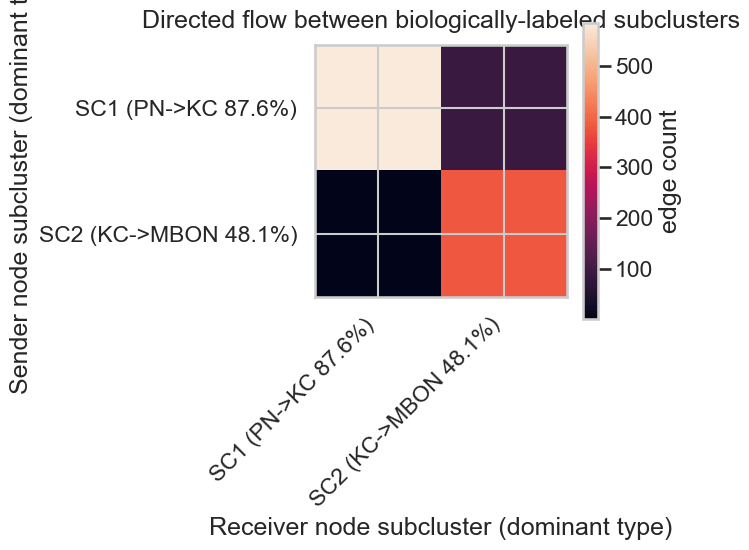

In [72]:
import matplotlib.pyplot as plt

# flow is your crosstab matrix (sender_label vs receiver_label)
# e.g., flow = pd.crosstab(sender_label, receiver_label)

xlabels = [subcluster_name.get(int(c), str(c)) for c in flow.columns]
ylabels = [subcluster_name.get(int(r), str(r)) for r in flow.index]

plt.figure(figsize=(7,6))
plt.imshow(flow.values)
plt.xticks(range(flow.shape[1]), xlabels, rotation=45, ha="right")
plt.yticks(range(flow.shape[0]), ylabels)
plt.xlabel("Receiver node subcluster (dominant type)")
plt.ylabel("Sender node subcluster (dominant type)")
plt.title("Directed flow between biologically-labeled subclusters")
plt.colorbar(label="edge count")
plt.tight_layout()
plt.show()


In [73]:
for c in sorted(sub["sub_cluster"].unique()):
    s = sub[sub["sub_cluster"] == c]
    src = (s["pre_type"].value_counts(normalize=True)*100).round(1).to_dict()
    tgt = (s["post_type"].value_counts(normalize=True)*100).round(1).to_dict()
    print(f"Subcluster {c}: edges={len(s)} | source mix={src} | target mix={tgt}")


Subcluster 1: edges=611 | source mix={'PN': 100.0} | target mix={'KC': 87.6, 'PN': 12.4}
Subcluster 2: edges=447 | source mix={'MBON': 48.1, 'KC': 48.1, 'PN': 3.8} | target mix={'MBON': 99.8, 'PN': 0.2}


Subcluster 1: PN -> KC (feedforward)
Subcluster 2: MBON -> MBON (recurrent)


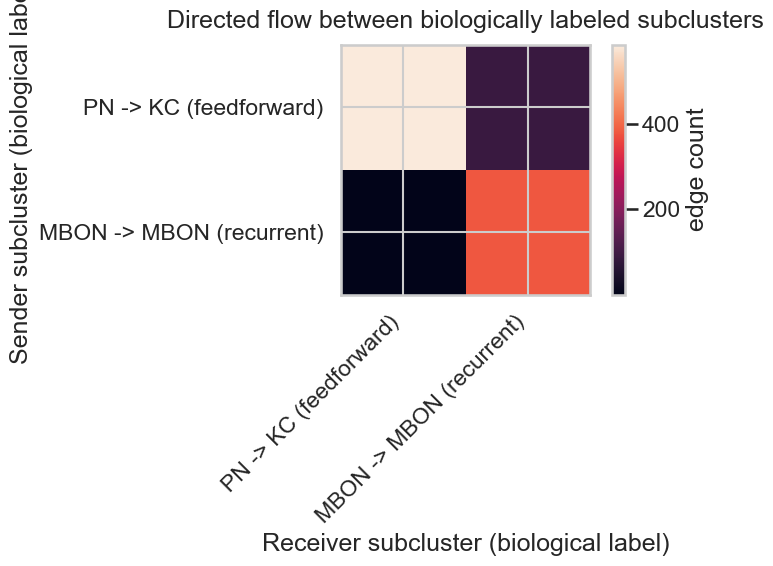

In [74]:
# --- Step 1: infer a biological label per subcluster from edge composition ---

subcluster_labels = {}

for c in sorted(sub["sub_cluster"].unique()):
    s = sub[sub["sub_cluster"] == c]

    src = s["pre_type"].value_counts(normalize=True)
    tgt = s["post_type"].value_counts(normalize=True)

    # dominant types
    src_dom, src_pct = src.idxmax(), src.max()
    tgt_dom, tgt_pct = tgt.idxmax(), tgt.max()

    # rule-based but data-driven naming
    if src_dom == "PN" and tgt_dom == "KC":
        name = "PN -> KC (feedforward)"
    elif src_dom == "KC" and tgt_dom == "MBON":
        name = "KC -> MBON (feedforward)"
    elif src_dom == "PN" and tgt_dom == "PN":
        name = "PN -> PN (recurrent)"
    elif src_dom == "MBON" and tgt_dom == "MBON":
        name = "MBON -> MBON (recurrent)"
    else:
        name = f"{src_dom} -> {tgt_dom} (mixed)"

    subcluster_labels[c] = name

# Print for confirmation
for k, v in subcluster_labels.items():
    print(f"Subcluster {k}: {v}")

# --- Step 2: label sender/receiver subclusters in the heatmap ---

xlabels = [subcluster_labels.get(int(c), str(c)) for c in flow.columns]
ylabels = [subcluster_labels.get(int(r), str(r)) for r in flow.index]

plt.figure(figsize=(8,6))
plt.imshow(flow.values)
plt.xticks(range(flow.shape[1]), xlabels, rotation=45, ha="right")
plt.yticks(range(flow.shape[0]), ylabels)
plt.xlabel("Receiver subcluster (biological label)")
plt.ylabel("Sender subcluster (biological label)")
plt.title("Directed flow between biologically labeled subclusters")
plt.colorbar(label="edge count")
plt.tight_layout()
plt.show()


In [75]:
rows = []
for c in sorted(sub["sub_cluster"].unique()):
    s = sub[sub["sub_cluster"] == c]
    rows.append({
        "subcluster": c,
        "label": subcluster_labels[c],
        "edges": len(s),
        "source_mix": (s["pre_type"].value_counts(normalize=True)*100).round(1).to_dict(),
        "target_mix": (s["post_type"].value_counts(normalize=True)*100).round(1).to_dict(),
    })

summary_df = pd.DataFrame(rows)
summary_df


,subcluster,label,edges,source_mix,target_mix
0,1,PN -> KC (feedforward),611,{'PN': 100.0},"{'KC': 87.6, 'PN': 12.4}"
1,2,MBON -> MBON (recurrent),447,"{'MBON': 48.1, 'KC': 48.1, 'PN': 3.8}","{'MBON': 99.8, 'PN': 0.2}"


We did not give bimodularity the idea of communities; we only gave it a place to look.
The communities emerged because the directed edge statistics are not random.
If PN/KC/MBON neurons were wired randomly among themselves, would bimodularity still find a dominant PN-sending / KC-receiving pipeline? No. 
The structure is coming from the biology encoded in the edges.

for the methods section:
Subgraph selection and validity of bimodularity analysis.
To focus on a biologically coherent subsystem while avoiding dilution of directed structure, we restricted the analysis to neurons annotated as projection neurons (PNs), Kenyon cells (KCs), and mushroom body output neurons (MBONs). This restriction was applied only at the level of node selection, all directed synaptic connections among these neurons were retained, including recurrent and feedback edges (e.g., PN→PN, KC→KC, MBON→MBON). No assumptions were made regarding the number, identity, or direction of communities.

Bimodularity was then applied to this induced subgraph using a degree-preserving out–in null model. Directed communities emerged solely from statistical deviations of observed edge patterns from the null expectation. In particular, a dominant directed bicommunity was identified whose sending side was enriched in PNs and whose receiving side was enriched in KCs and MBONs. Reapplying the same bimodularity-based edge clustering within this dominant bicommunity revealed a hierarchical decomposition into upstream PN→KC and downstream KC→MBON substructures.

Thus, the detected communities were not imposed by anatomical labels or directional constraints, but instead arose from the intrinsic directed connectivity structure of the circuit relative to the null model.

biomodularity then comes in to ask:
Are there sets of nodes that, as SENDERS,
connect to sets of nodes that, as RECEIVERS,
more than expected by chance?